In [2]:
import pandas as pd 
import numpy as np 
import ternary
import json
import os 
from datetime import datetime
from analysis_tools import get_df_from_ML_optimization


def reformat_timestamp(ts):
    return datetime.strptime(ts, "%d.%m.%Y_%H-%M").strftime("%d_%m_%Y_%H_%M")


subdir_og = "Ni_Mo_optimization_run_01_05_25/ML"
path_suggested_exps_og = "ML_data/Strat_3_hybrid/Suggested_exps"
path_input_params_og = os.path.join("ML_data/Strat_3_hybrid", "Input_parameters_database.json")
path_goal_params_og = os.path.join("ML_data/Strat_3_hybrid", "Goal_parameters_database.json")

# Beta = 5 run
subdir_beta_5 = "Ni_Mo_Optimization_Jonas/ML/Beta_5"
path_suggested_exps_beta_5 = "ML_data/UCB_beta_5/Suggested_exps"
path_input_params_beta_5 = os.path.join("ML_data/UCB_beta_5", "Input_parameters_database.json")
path_goal_params_beta_5 = os.path.join("ML_data/UCB_beta_5", "Goal_parameters_database.json")

# Beta = 1 run
subdir_beta_1 = "Ni_Mo_Optimization_Jonas/ML/Beta_1"
path_suggested_exps_beta_1 = "ML_data/UCB_beta_1"
path_input_params_beta_1 = os.path.join("ML_data/UCB_beta_1", "Input_parameters_database.json")
path_goal_params_beta_1 = os.path.join("ML_data/UCB_beta_1", "Goal_parameters_database.json")

# Original dataset
df_og = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_og, 
                            path_input_params=path_input_params_og, 
                            path_goal_params=path_goal_params_og)

# Optimization run fixed beta = 5 
df_beta_5 = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_beta_5, 
                            path_input_params=path_input_params_beta_5, 
                            path_goal_params=path_goal_params_beta_5)

# Optimization run fixed beta = 1
df_beta_1 = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_beta_1, 
                            path_input_params=path_input_params_beta_1, 
                            path_goal_params=path_goal_params_beta_1)

# This dataset includes also data with IR corrections 
datasets = [df_og, df_beta_5, df_beta_1]


complete_dataset = pd.concat(datasets, ignore_index=True)
complete_dataset["timestamp"] = complete_dataset["timestamp"].apply(reformat_timestamp)

# Strategy 3 improvement curve (hybrid)

/var/folders/y7/nkq5y8bx3nl3kcn3ndsw71t80000gp/T/ipykernel_69540/2611025079.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phases["index"] = phases.index


[(0, 15, ['qMaxValueEntropySearch', 0.0]), (16, 35, ['qUpperConfidenceBound', 4.0]), (36, 52, ['qUpperConfidenceBound', 3.0]), (53, 72, ['qMaxValueEntropySearch', 0.0]), (73, 89, ['qUpperConfidenceBound', 4.0])]


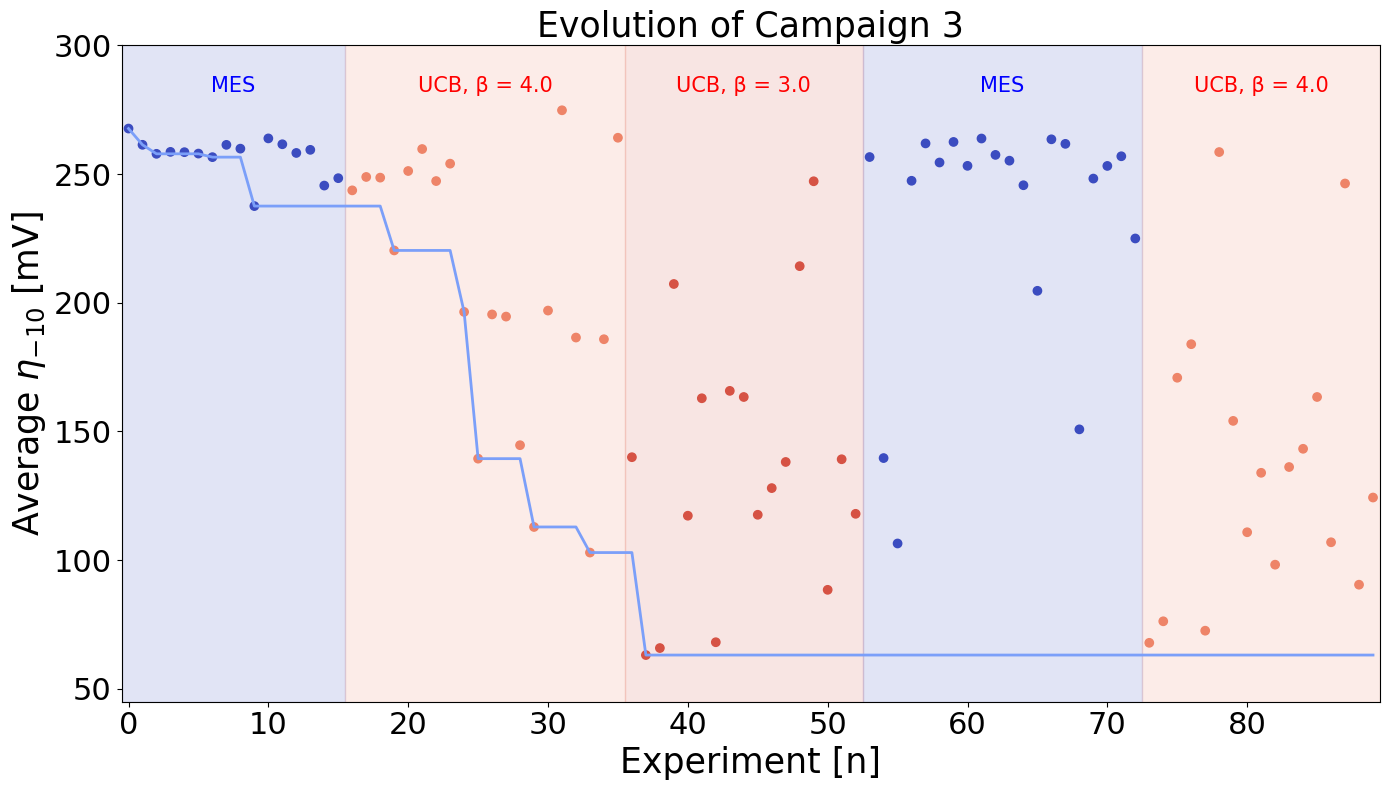

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.ticker import MaxNLocator
import os 
# Use a red-to-blue colormap
cmap = plt.get_cmap("coolwarm")

# Define beta-to-color mapping
beta_colors = {
    0: cmap(0.0),    # red
    4: cmap(0.8),
    3: cmap(0.9),
    2: cmap(0.6),
    1: cmap(0.8),
    0.5: cmap(1.0)   # blue
}

plot_df = df_og.iloc[:90]

integrated_areas = plot_df["integrated_area"] / 100
ML_optimization = plot_df["ML_optimization"]
betas = plot_df["qUpperConfidence_beta"]


colors = [beta_colors.get(b, 'gray') for b in betas]

# Prepare the top legend strip (outside the plot)
unique_phases = df_og[["ML_optimization", "qUpperConfidence_beta"]].drop_duplicates()
unique_phases = unique_phases.sort_values("ML_optimization")  # Optional: sort by phase name


fig, ax = plt.subplots(figsize=(14, 8))

# Use same x and colors as before
x = np.arange(len(integrated_areas))
colors = [beta_colors.get(b, 'gray') for b in betas]

# Scatter points with color code
ax.scatter(x, integrated_areas, color=colors)

# Plot the evolution line (minimum up to each point)
min_integrated_area = integrated_areas.iloc[0]
evolution_line = []
for val in integrated_areas:
    if val < min_integrated_area:
        min_integrated_area = val
    evolution_line.append(min_integrated_area)

ax.plot(evolution_line, color=cmap(0.2), label="Best-so-far", lw = 2)
# Get start/end indices of each phase
phases = plot_df[["ML_optimization", "qUpperConfidence_beta"]]
phases["index"] = phases.index

# Group by consecutive identical phases
from itertools import groupby
from operator import itemgetter

phase_blocks = []
for k, g in groupby(enumerate(phases[["ML_optimization", "qUpperConfidence_beta"]].values.tolist()), key=itemgetter(1)):
    g = list(g)
    indices = [i for i, _ in g]
    phase_blocks.append((indices[0], indices[-1], k))

# Draw shaded spans and add labels
for start, end, (ml_opt, beta) in phase_blocks:
    color = beta_colors.get(beta, "gray")
    label = "MES" if beta == 0 else f"UCB, β = {beta}"
    
    label_color = "blue" if beta == 0 else "red"
    # Shading
    ax.axvspan(start - 0.5, end + 0.5, color=color, alpha=0.15)
    
    # Centered text label
    center = (start + end) / 2
    max_y = max(integrated_areas) * 1.02
    ax.text(center, max_y, label, color=label_color, ha="center", va="bottom", fontsize=15)

print(phase_blocks)
# Labels and formatting
ax.set_ylim(45, 300)
ax.set_xlim(min(start for start, _, _ in phase_blocks) - 0.5,
            max(end for _, end, _ in phase_blocks) + 0.5)
ax.set_xlabel("Experiment [n]", fontsize=25)
ax.set_ylabel(r"Average $\eta_{-10}$ [mV]", fontsize=25)
ax.tick_params(labelsize=22)
ax.set_title("Evolution of Campaign 3", fontsize = 25)
#ax.legend(fontsize=20, loc = "lower left")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Investigating the different strategies

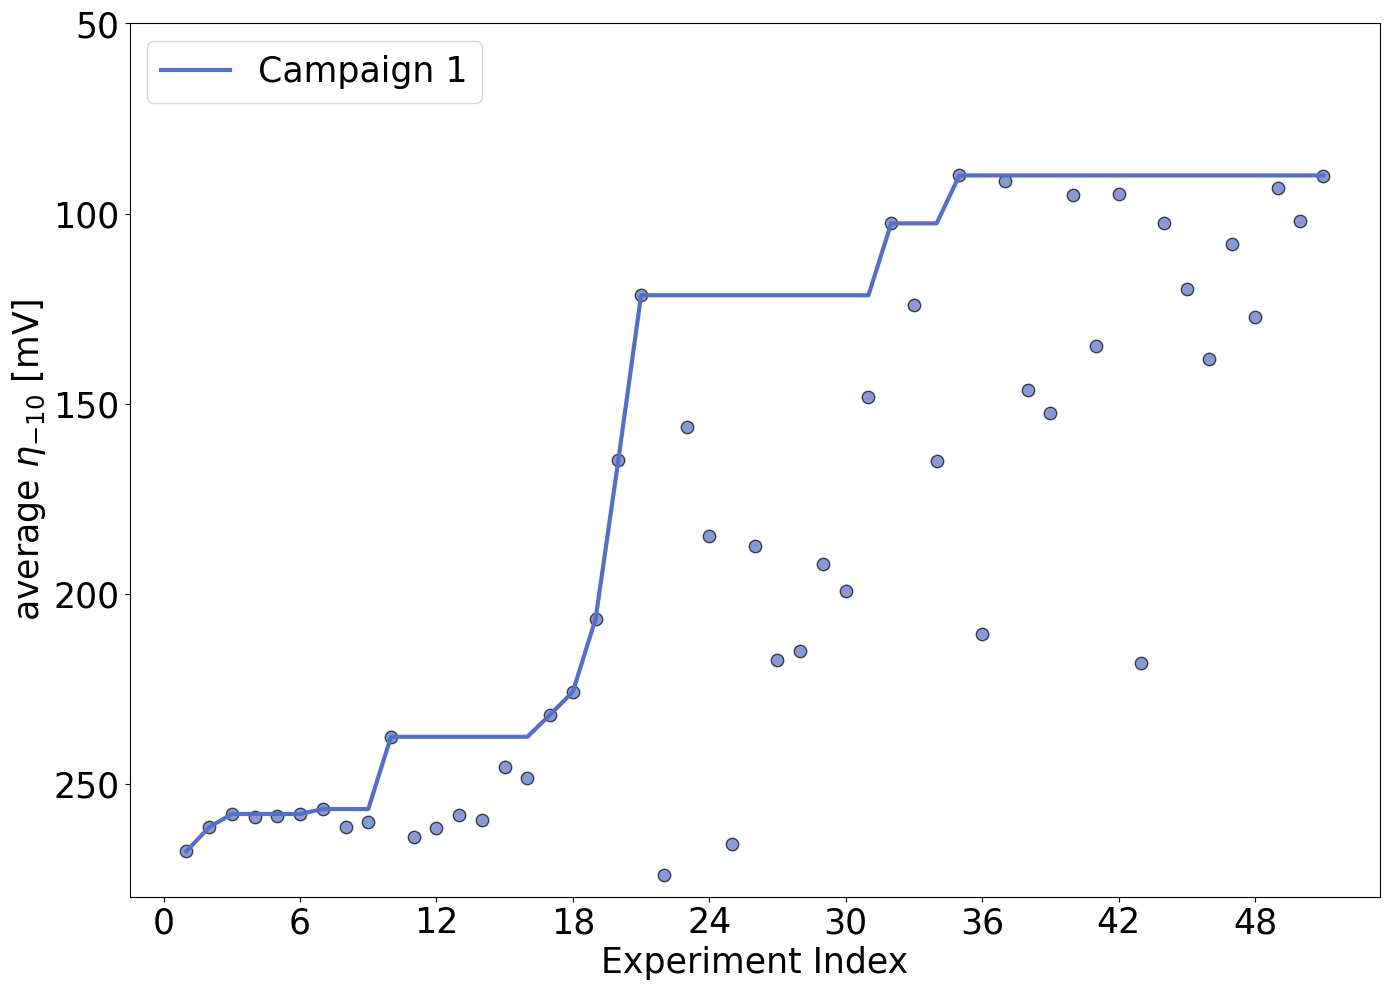

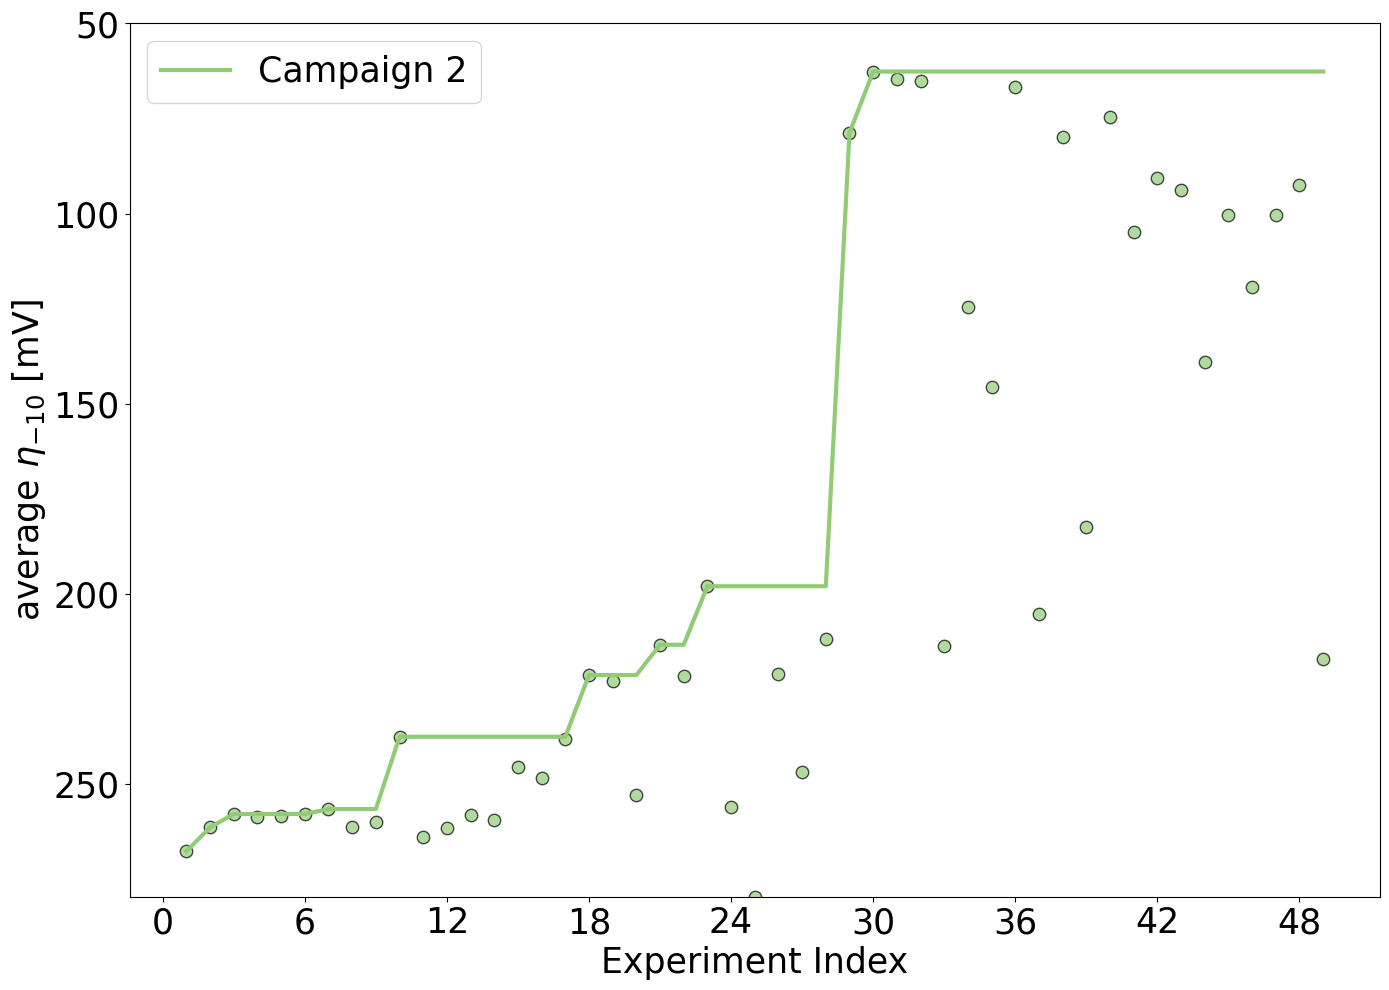

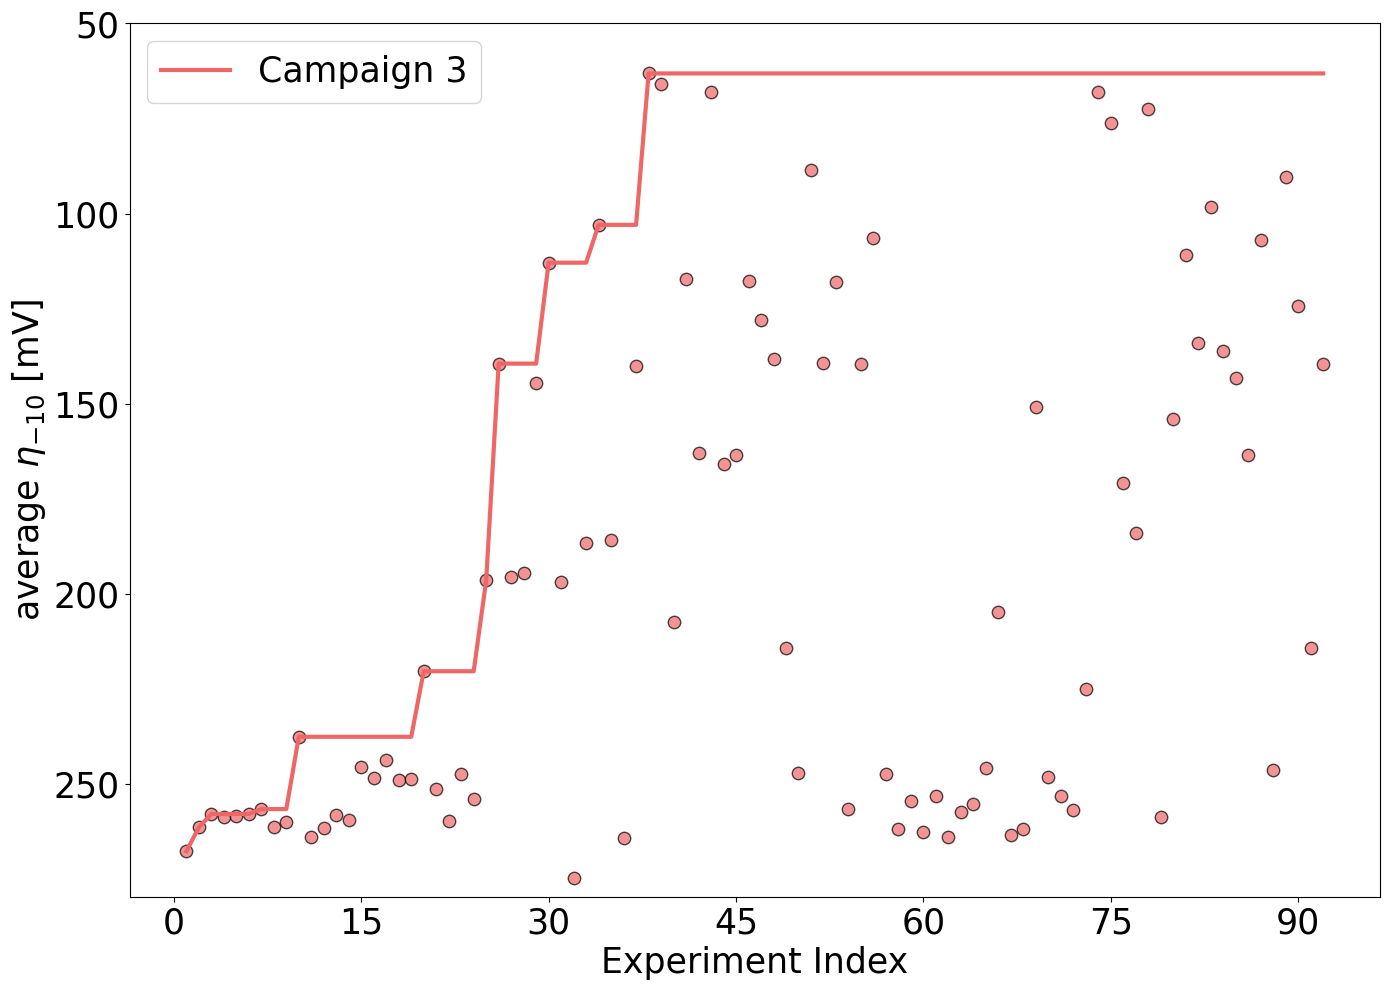

In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.ticker import MaxNLocator
import os
from itertools import groupby
from operator import itemgetter
from matplotlib.patches import Patch

# Use a qualitative colormap for distinct categories
cmap = plt.get_cmap("coolwarm")  # Good alternatives: "Set1", "Dark2", "Paired"

save_path_BO_examples = "Figures/BO"
# Distinct colors for each beta
beta_colors = {
    0: cmap(0),    # blue
    4: cmap(1),    # orange
    3: cmap(2),    # green
    2: cmap(3),    # red
    1: cmap(4),    # purple
    0.5: cmap(5)   # brown
}

def plot_trace(df, ax, label_prefix, line_color, use_beta_coloring=False):
    integrated_areas = df["integrated_area"] / 100
    betas = df["qUpperConfidence_beta"]
    x = np.arange(len(integrated_areas)) + 1

    if use_beta_coloring:
        # Per-point color by beta
        for i, (x_i, y_i, beta) in enumerate(zip(x, integrated_areas, betas)):
            color = beta_colors.get(beta, "gray")
            ax.scatter(x_i, y_i, color=line_color, edgecolors='k', alpha=0.8, s=80)
    else:
        ax.scatter(x, integrated_areas, color=line_color, edgecolors='k', alpha=0.7, s=80)

    # Best-so-far line
    min_area = integrated_areas.iloc[0]
    evolution_line = []
    for val in integrated_areas:
        if val < min_area:
            min_area = val
        evolution_line.append(min_area)
    ax.plot(x, evolution_line, color=line_color, label=f"{label_prefix}", linewidth=3)

    return integrated_areas


# Plot
# Plot 1: df_og (Campaign 1)
# --- Compute shared y-limit max ---
ymin = 50
ymin = 50
ymax = max(
    max(df_og["integrated_area"] / 100),
    max(df_beta_1["integrated_area"] / 100),
    max(df_beta_5["integrated_area"] / 100), )
    


# Add color codes from spider plot 
colors = {"beta_1" : "#5470c6",
          "beta_5" : "#91cc75", 
          "original": "#ee6666"}

# Plot 2: df_beta_1 (Campaign 2)
fig2, ax2 = plt.subplots(figsize=(14, 10))
areas_beta_1 = plot_trace(df_beta_1, ax2, "Campaign 1", line_color=colors["beta_1"])
ax2.set_ylim(ymax, ymin)  # Flipped here directly
ax2.set_xlabel("Experiment Index", fontsize=25)
ax2.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax2.tick_params(labelsize=25)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(loc="upper left", fontsize=25)
plt.tight_layout()
#plt.savefig(os.path.join(save_path_BO_examples, "Campaign_1_Optimization.png"))

# Plot 3: df_beta_5 (Campaign 3)
fig3, ax3 = plt.subplots(figsize=(14, 10))
areas_beta_5 = plot_trace(df_beta_5, ax3, "Campaign 2", line_color=colors["beta_5"])
ax3.set_ylim(ymax, ymin)  # Flipped here directly
ax3.set_xlabel("Experiment Index", fontsize=25)
ax3.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax3.tick_params(labelsize=25)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.legend(loc="upper left", fontsize=25)
plt.tight_layout()
#plt.savefig(os.path.join(save_path_BO_examples, "Campaign_2_Optimization.png"))


# Here change the colors 
# Plot 1: df_og (Campaign 1)
fig1, ax1 = plt.subplots(figsize=(14, 10))
areas_og = plot_trace(df_og, ax1, "Campaign 3", line_color=colors["original"])
ax1.set_ylim(ymax, ymin)  # Flipped here directly
ax1.set_xlabel("Experiment Index", fontsize=25)
ax1.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax1.tick_params(labelsize=25)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend(loc="upper left", fontsize=25)
plt.tight_layout()
#plt.savefig(os.path.join(save_path_BO_examples, "Campaign_3_Optimization.png"))


# Parameter choices for the BO algorithm during optimization

Index(['NiSO4 (mol/L)', 'Na2Mo (mol/L)', 'H2SO4 (mol/L)', 'Dep t (s)',
       'Dep I (mA/cm²)', 'Dep T (C)', 'integrated_area', 'ML_optimization',
       'timestamp', 'qUpperConfidence_beta'],
      dtype='object')


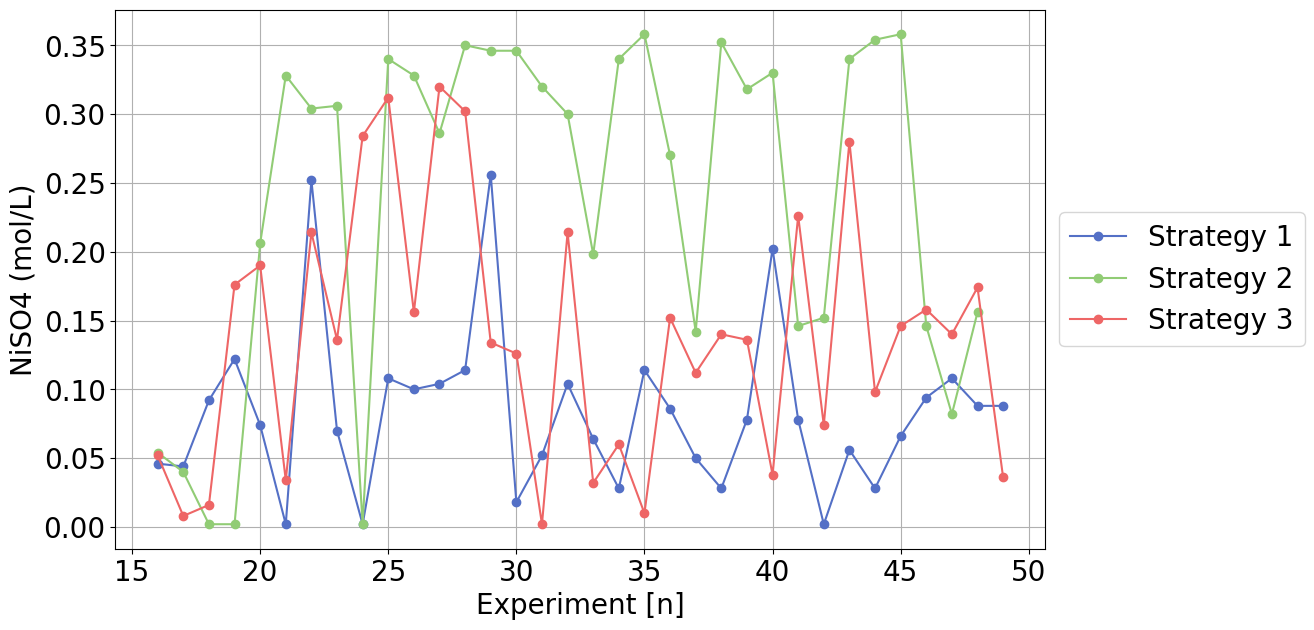

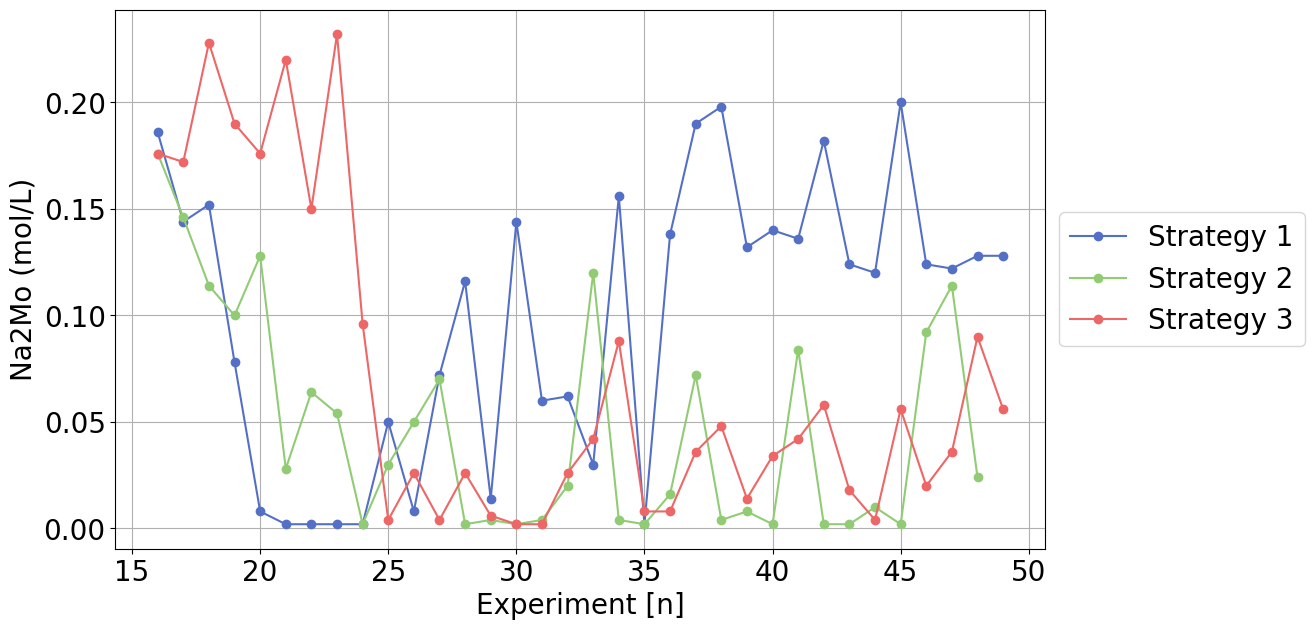

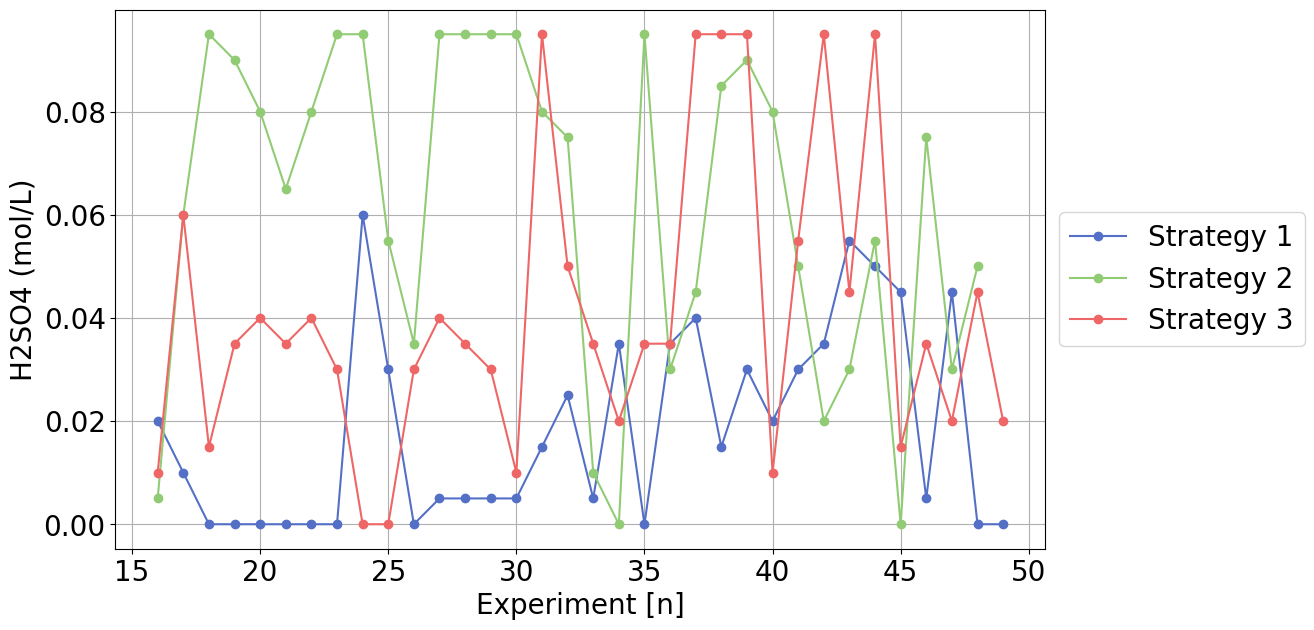

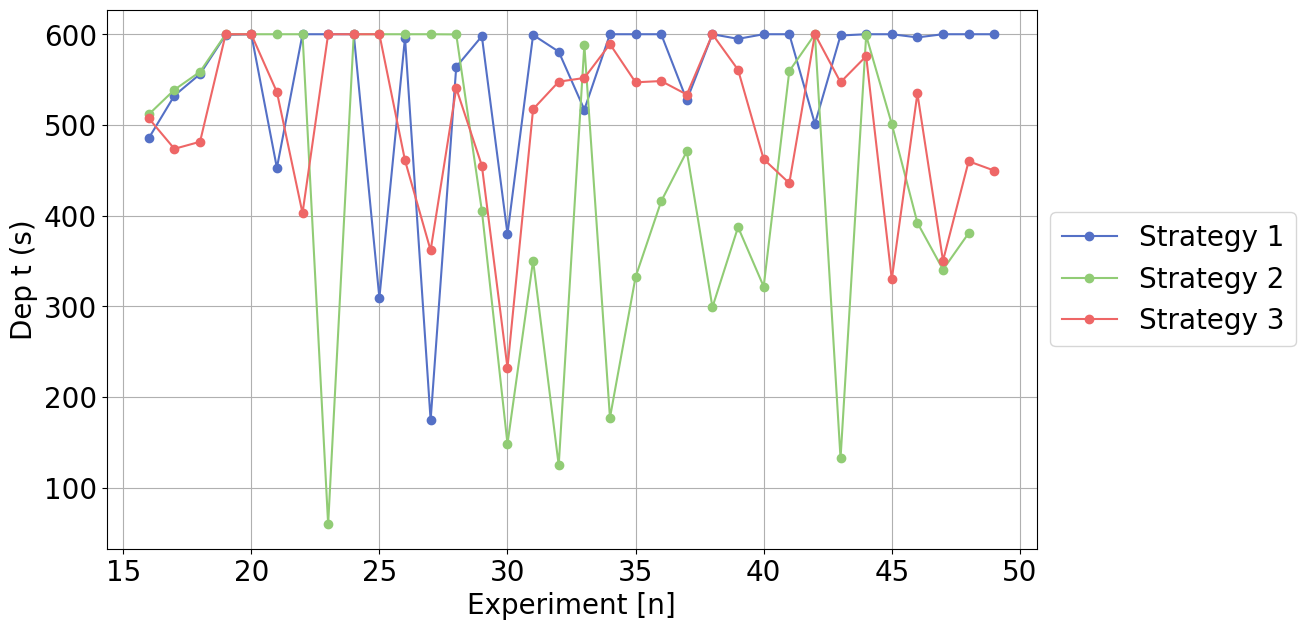

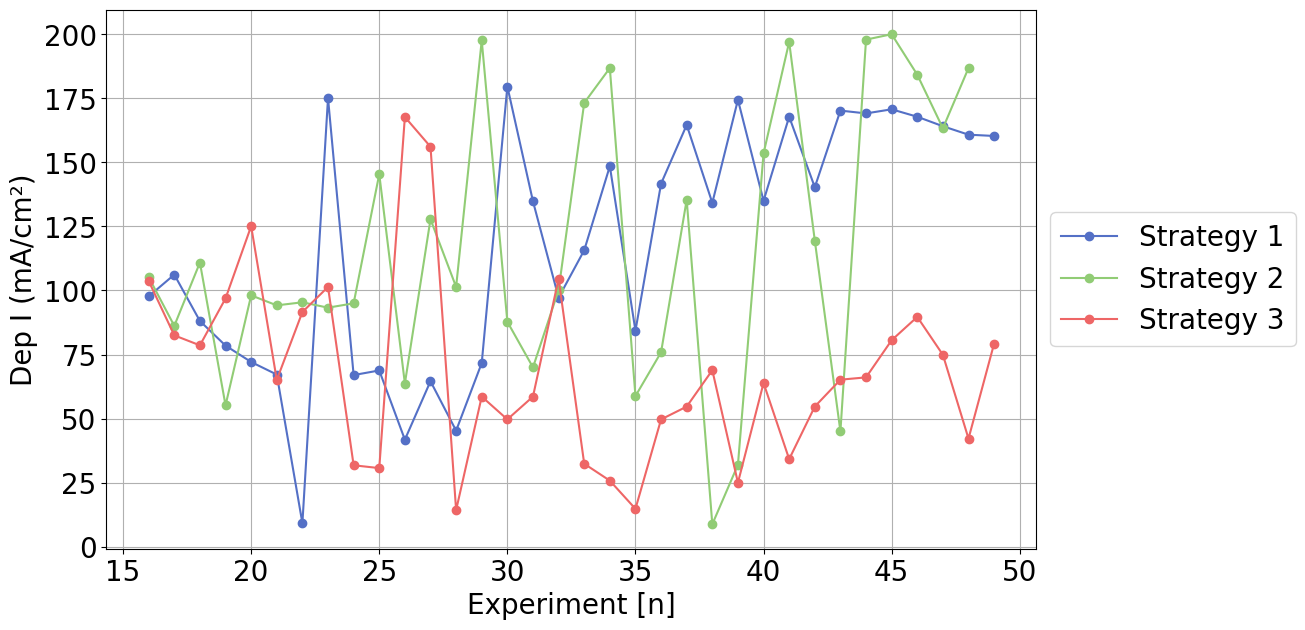

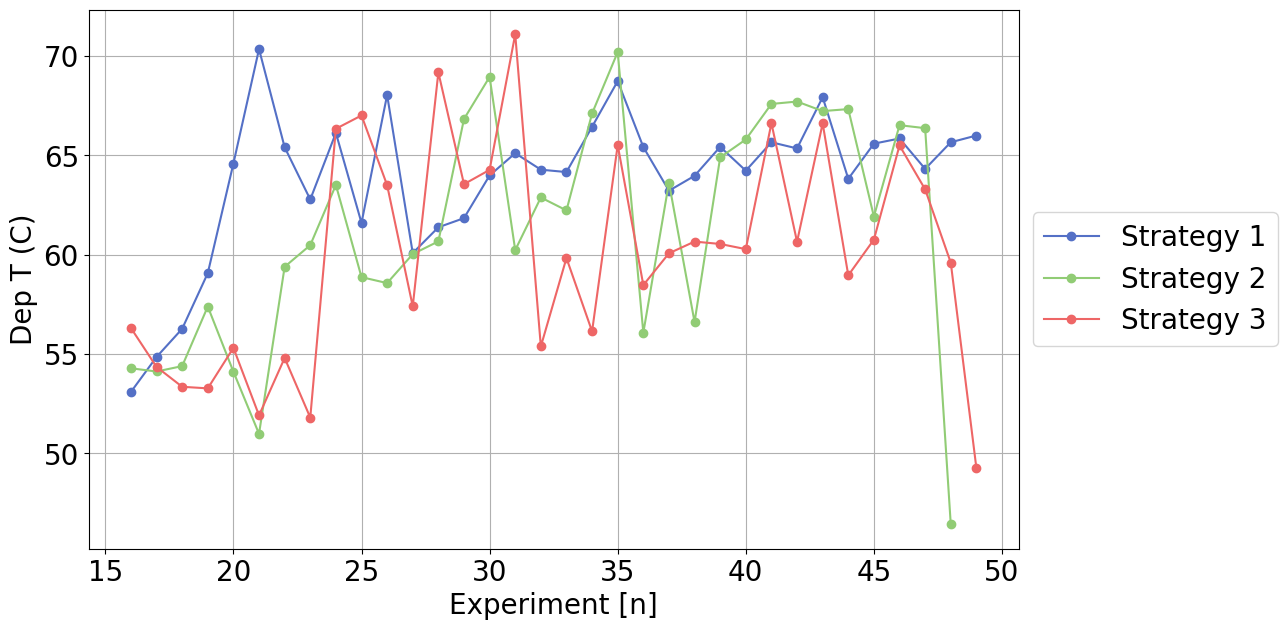

In [5]:
colors = ["#91cc75", "#5470c6", "#ee6666", "red", "purple", "black"]

params = [
    "NiSO4 (mol/L)",  
    "Na2Mo (mol/L)",  
    "H2SO4 (mol/L)", 
    "Dep t (s)", 
    "Dep I (mA/cm²)", 
    "Dep T (C)"
]

colors = {"Strategy 1" : "#5470c6",
          "Strategy 2" : "#91cc75", 
          "Strategy 3": "#ee6666"}
datasets = [df_beta_1,df_beta_5,  df_og]

print(df_beta_1.columns)
labels = ["Strategy 1", "Strategy 2", "Strategy 3"]
for i, param in enumerate(params):
    plt.figure(figsize = (12, 7))
    for idx, data in enumerate(datasets):

        # Make sure the DataFrame is sorted by time or index
        data = data.copy().reset_index(drop=True)

        # Plot each parameter vs experiment iteration
        n_params = len(params)
        color = colors[f"Strategy {idx + 1}"]
        try:

            plt.plot(data.index[16:50], data[param][16:50], marker='o', linestyle='-', color = color, label = labels[idx])
        except:
            plt.plot(data.index[16:], data[param][16:], marker='o', linestyle='-', color = color, label = labels[idx])
    plt.ylabel(param, fontsize = 20)
    plt.xlabel("Experiment [n]", fontsize = 20)
    plt.grid()
    
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=20)
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)
    if param == 'Dep t (s)':
        param_str = "Dep_t_s"
    else:
        param_str = param.split(" (")[0]
    #plt.savefig(f"model_paths_{param_str}.png", bbox_inches="tight")

    plt.show()



# Investigaing best points for each strategy

In [6]:
# Define the columns to print
import matplotlib.pyplot as plt

# Work on copies instead of modifying the original DataFrames
df_beta_5_mod = df_beta_5.copy()
df_beta_1_mod = df_beta_1.copy()
df_og_mod     = df_og.copy()

n_to_show = 10
# Apply transformations

df_beta_5_mod["C_dep"] = df_beta_5_mod["Dep I (mA/cm²)"] * df_beta_5_mod["Dep t (s)"] / 96485
df_beta_5_mod["Citrate (mol/L)"] = df_beta_5_mod["NiSO4 (mol/L)"] + df_beta_5_mod['Na2Mo (mol/L)'] 
df_beta_5_mod["NiSO4 (mol/L)"] = df_beta_5_mod["NiSO4 (mol/L)"] + df_beta_5_mod['Na2Mo (mol/L)'] * 0.1
df_beta_5_mod['Na2Mo (mol/L)'] = df_beta_5_mod['Na2Mo (mol/L)'] + df_beta_5_mod["NiSO4 (mol/L)"] * 0.1

df_beta_1_mod["C_dep"] = df_beta_1_mod["Dep I (mA/cm²)"] * df_beta_1_mod["Dep t (s)"]/ 96485
df_beta_1_mod["Citrate (mol/L)"] = df_beta_1_mod["NiSO4 (mol/L)"] + df_beta_1_mod['Na2Mo (mol/L)'] 
df_beta_1_mod["NiSO4 (mol/L)"] = df_beta_1_mod["NiSO4 (mol/L)"] + df_beta_1_mod['Na2Mo (mol/L)'] * 0.1
df_beta_1_mod['Na2Mo (mol/L)'] = df_beta_1_mod['Na2Mo (mol/L)'] + df_beta_1_mod["NiSO4 (mol/L)"] * 0.1

df_og_mod["C_dep"] = df_og_mod["Dep I (mA/cm²)"] * df_og_mod["Dep t (s)"]/ 96485
df_og_mod["Citrate (mol/L)"] = df_og_mod["NiSO4 (mol/L)"] + df_og_mod['Na2Mo (mol/L)'] 
df_og_mod["NiSO4 (mol/L)"] = df_og_mod["NiSO4 (mol/L)"] + df_og_mod['Na2Mo (mol/L)'] * 0.1
df_og_mod['Na2Mo (mol/L)'] = df_og_mod['Na2Mo (mol/L)'] + df_og_mod["NiSO4 (mol/L)"] * 0.1


columns_to_show = ["NiSO4 (mol/L)", "Na2Mo (mol/L)", "H2SO4 (mol/L)", 
                   "Dep t (s)", "Dep I (mA/cm²)","C_dep", "Dep T (C)", "Citrate (mol/L)", "integrated_area", "timestamp", ]

# Create top and bottom DataFrames for each strategy (on modified copies)
tail_beta_5 = df_beta_5_mod.sort_values("integrated_area").tail(n_to_show)[columns_to_show]
head_beta_5 = df_beta_5_mod.sort_values("integrated_area").head(n_to_show)[columns_to_show]

tail_beta_1 = df_beta_1_mod.sort_values("integrated_area").tail(n_to_show)[columns_to_show]
head_beta_1 = df_beta_1_mod.sort_values("integrated_area").head(n_to_show)[columns_to_show]

tail_og = df_og_mod.sort_values("integrated_area").tail(n_to_show)[columns_to_show]
head_og = df_og_mod.sort_values("integrated_area").head(n_to_show)[columns_to_show]

F = 96485

# Print results
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print("-" * 25, "Strategy 3", "_" * 25)
    print(head_og)
    print()
    print("-" * 25, "Strategy 2", "_" * 25)
    print(head_beta_5)
    print()
    print("-" * 25, "Strategy 1", "_" * 25)
    print(head_beta_1)
    print("-" * 50)


------------------------- Strategy 3 _________________________
    NiSO4 (mol/L)  Na2Mo (mol/L)  H2SO4 (mol/L)  Dep t (s)  Dep I (mA/cm²)     C_dep  Dep T (C)  Citrate (mol/L)  integrated_area         timestamp
37         0.1156        0.04756          0.095      533.5            54.7  0.302456      60.07            0.148      6313.177205  06.05.2025_16-03
38         0.1448        0.06248          0.095      600.0            68.9  0.428460      60.66            0.188      6585.384448  06.05.2025_17-44
73         0.2214        0.05614          0.090      119.9           134.0  0.166519      66.10            0.252      6788.548841  11.05.2025_11-57
42         0.0798        0.06598          0.095      600.0            54.7  0.340157      60.65            0.132      6811.037222  07.05.2025_00-39
77         0.1064        0.07464          0.090      305.7            45.0  0.142577      65.07            0.164      7259.314944  11.05.2025_18-10
74         0.0664        0.07064          0.095  

# Parameter dependencies of $\langle\eta_{-10}\rangle$

Investigating how $NiSO_4$, $Na_2MoO_4$, $H_2SO_4$ concentrations as well as deposition time, deposition current density and temperature affects coating performance

$\mathbf{NiSO_4}$ (M)
$\mathbf{Na_2MoO_4}$ (M)
$\mathbf{H_2SO_4}$ (M)
Dep t (s)
Dep I (mA/cm²)
Dep T (C)


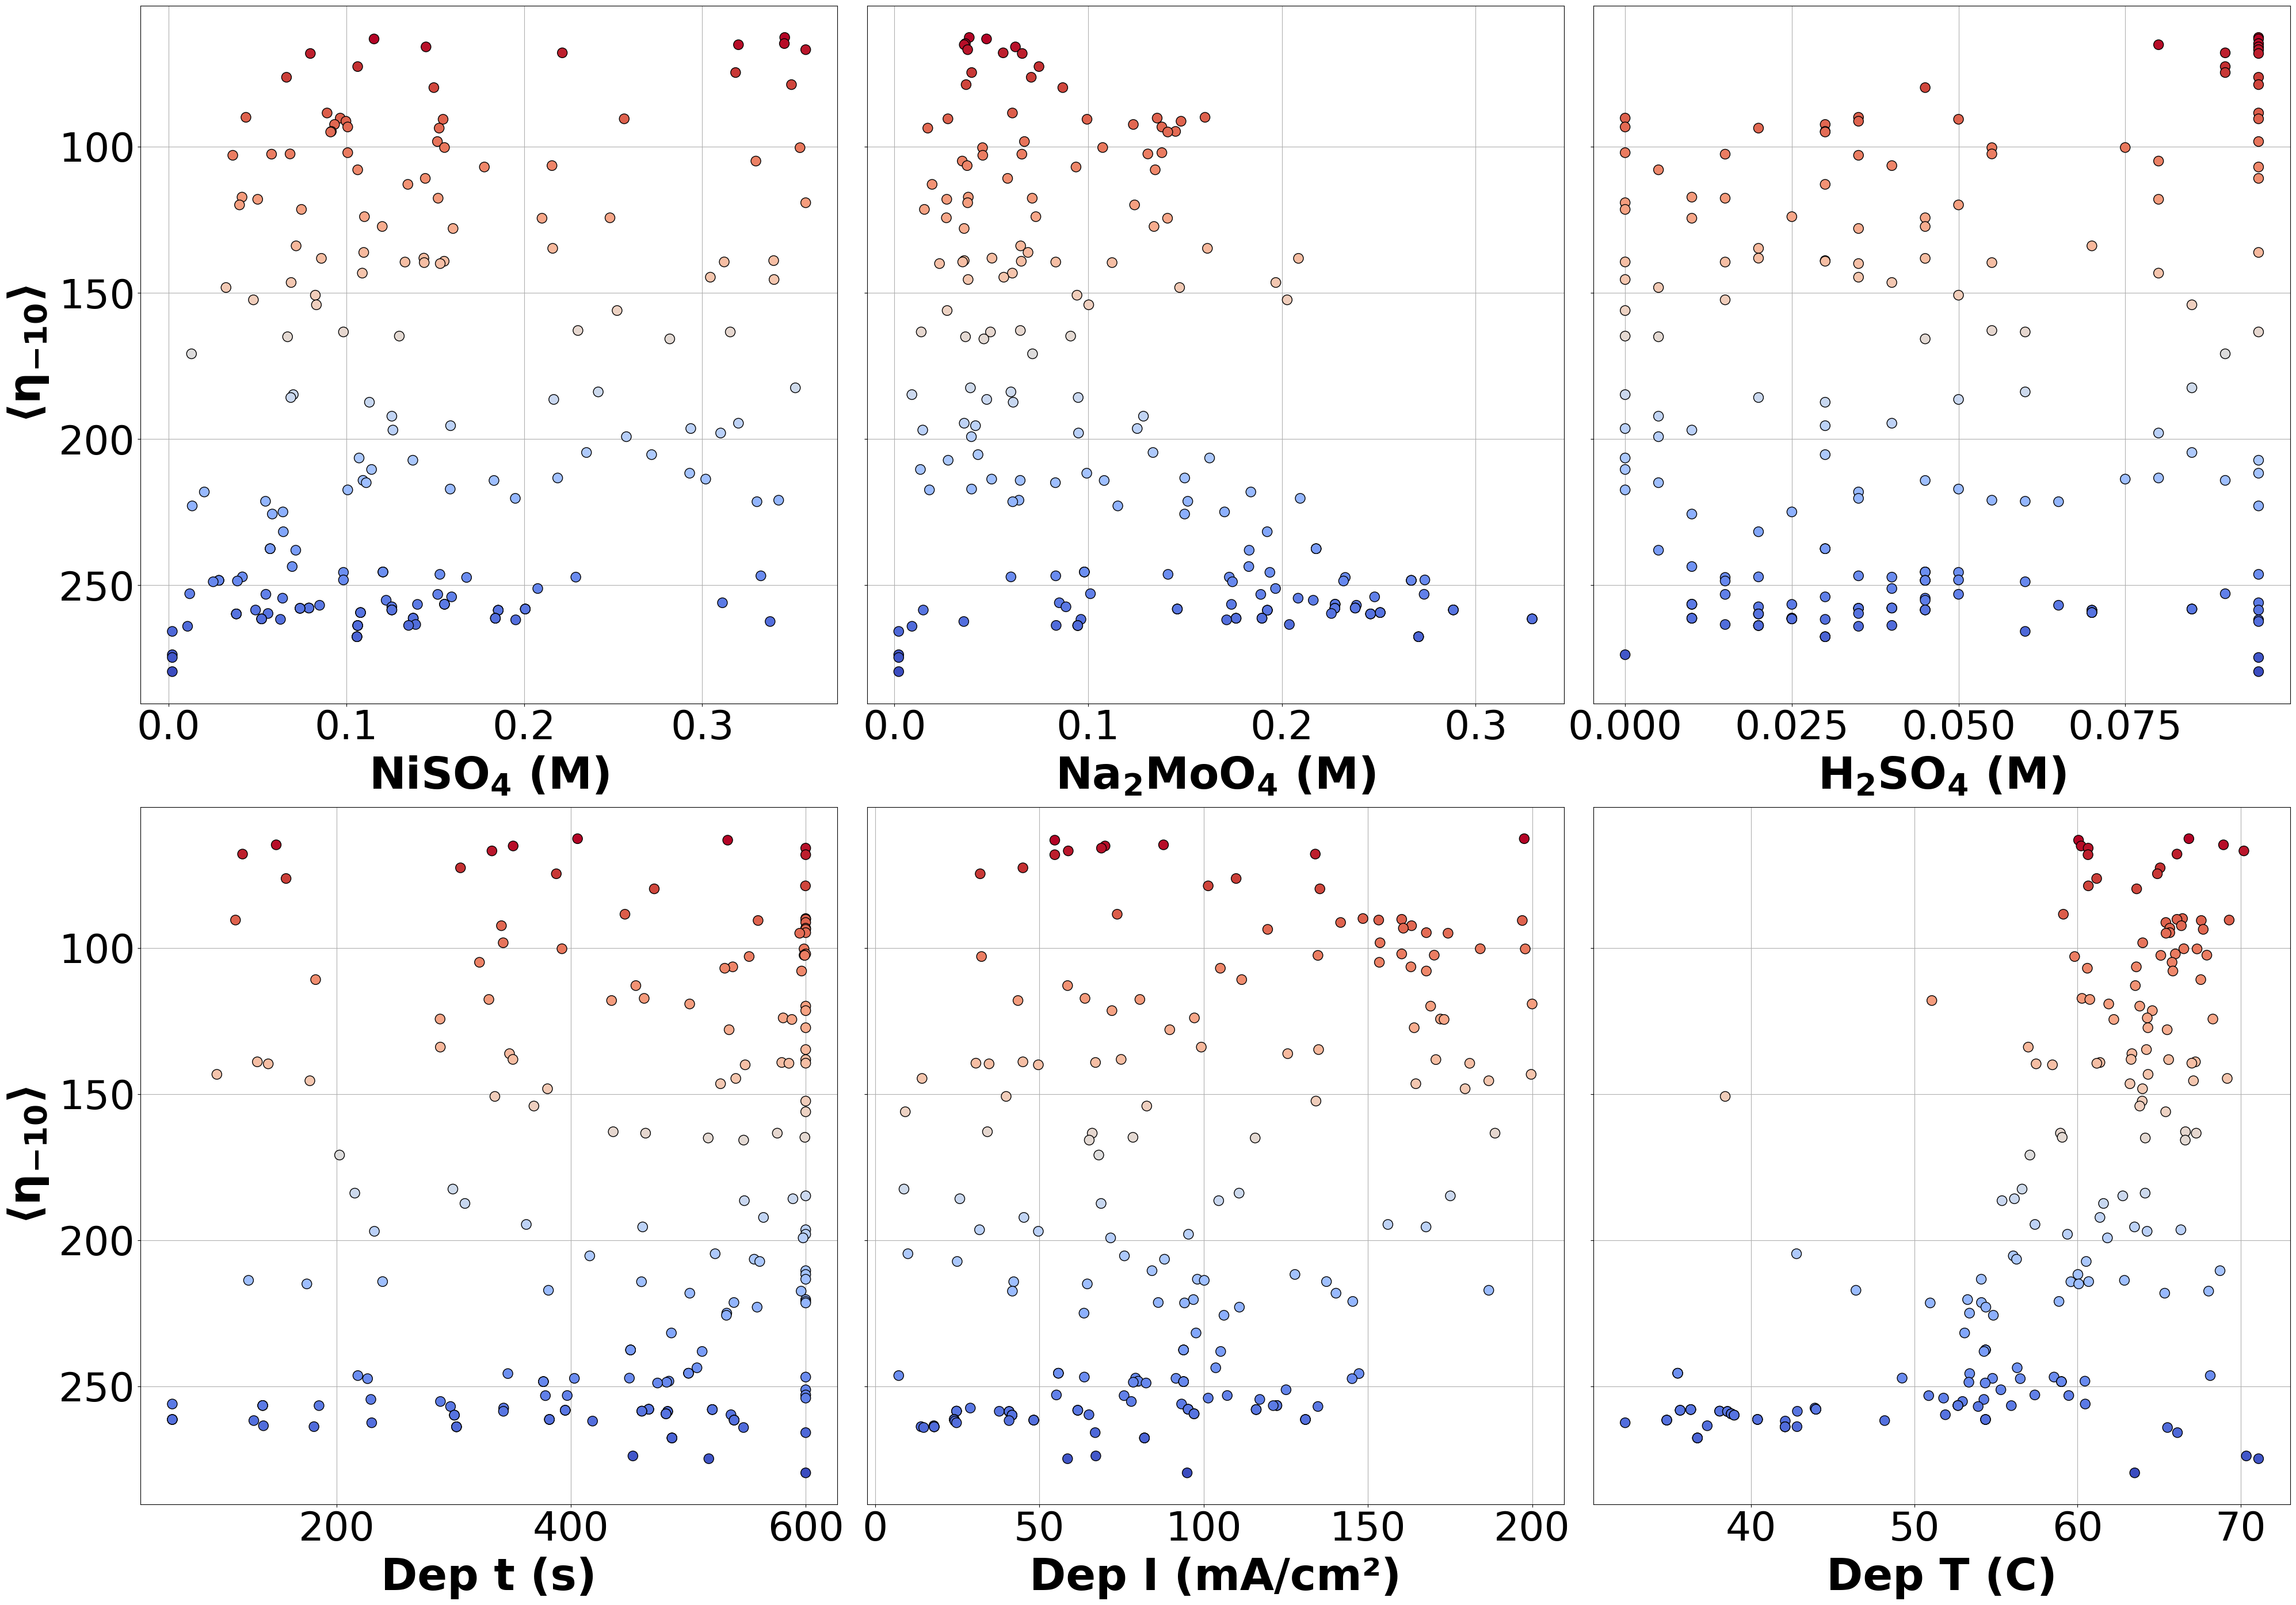

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import math 

# Combine datasets
complete_dataset = pd.concat([df_og, df_beta_5, df_beta_1], ignore_index=True) # Reset the complete dataset 
#complete_dataset.to_csv("complete_dataset.csv", index=False)
# Temperature in Kelvin
T = complete_dataset["Dep T (C)"] + 273.15

# Concentrations


# Compute D values and add to DataFrame
eV = 1.6 * 10 ** (-19)
kB = 1.38 * 10 ** (-23)

complete_dataset["C_dep"] = complete_dataset["Dep I (mA/cm²)"] * complete_dataset["Dep t (s)"] / 1000 * 0.97

complete_dataset["NiSO4 (mol/L)"] = complete_dataset["NiSO4 (mol/L)"] + complete_dataset['Na2Mo (mol/L)'] * 0.1
complete_dataset['Na2Mo (mol/L)'] = complete_dataset['Na2Mo (mol/L)'] + complete_dataset["NiSO4 (mol/L)"] * 0.1

C_Ni_SO4 = complete_dataset["NiSO4 (mol/L)"]
C_Na2Mo = complete_dataset["Na2Mo (mol/L)"]
complete_dataset["D_Ni"] = np.exp(-C_Ni_SO4 / (T))
complete_dataset["D_Mo"] = np.exp(-1 / (C_Na2Mo * T))
complete_dataset["Ni_Mo_r"] = C_Ni_SO4 / C_Na2Mo

# Update parameters for plotting
params = ["NiSO4 (mol/L)",  'Na2Mo (mol/L)', 'H2SO4 (mol/L)', 
          'Dep t (s)', 'Dep I (mA/cm²)', 'Dep T (C)']

# Sort and select
sorted_df = complete_dataset.copy().sort_values(by="integrated_area").reset_index(drop=True)

# Normalize integrated_area for color mapping
norm = plt.Normalize(sorted_df["integrated_area"].min(), sorted_df["integrated_area"].max())
colors = cm.coolwarm_r(norm(sorted_df["integrated_area"]))

savepath_params = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/Ni_Mo_paper/Plots_paper"
# Plot
fig, axes = plt.subplots(math.ceil(len(params) / 3), 3, figsize=(40, 28),sharey=True)  # Now 3x3 for 8 plots

axes = axes.flatten()
n_rows = math.ceil(len(params) / 2)

for i, param in enumerate(params):
    x_data = sorted_df[param]
    if param == "Na2Mo (mol/L)":
        param = r"$\mathbf{Na_2MoO_4}$ (M)"
    if param == "NiSO4 (mol/L)":
        param = r"$\mathbf{NiSO_4}$ (M)"
    if param == 'H2SO4 (mol/L)':
        param = r"$\mathbf{H_2SO_4}$ (M)"
    print(param)
    #axes[i].set_xlabel(param, fontsize=28)

    axes[i].scatter(
        x_data,
        sorted_df["integrated_area"] / 100,
        c=colors,
        edgecolors='k',
        s=150,  # dot size,
        zorder = 10
    )
    if i == 0:
        axes[0].invert_yaxis()
    #axes[i].set_title(param, fontsize=55, pad = 10)
    axes[i].set_xlabel(param, 
                    fontsize=55, 
                    labelpad=10, 
                    fontweight='bold')  # makes label bold
    axes[i].tick_params(axis='both', labelsize=50)
    if (i == 0 or i == 3):
        axes[i].set_ylabel(r"$\mathbf{\langle \eta_{-10} \rangle}$", 
                   fontsize=55, labelpad=10)

    axes[i].grid(True)
plt.subplots_adjust(hspace=0.15)
plt.tight_layout()

plt.savefig(os.path.join(savepath_params, "Param_dependencies.png"))
# Hide any unused subplot axes (if 9 total axes but only 8 params)
for j in range(len(params), len(axes)):
    fig.delaxes(axes[j])
# Prepare data



# Investigating the dependence on total amount deposited

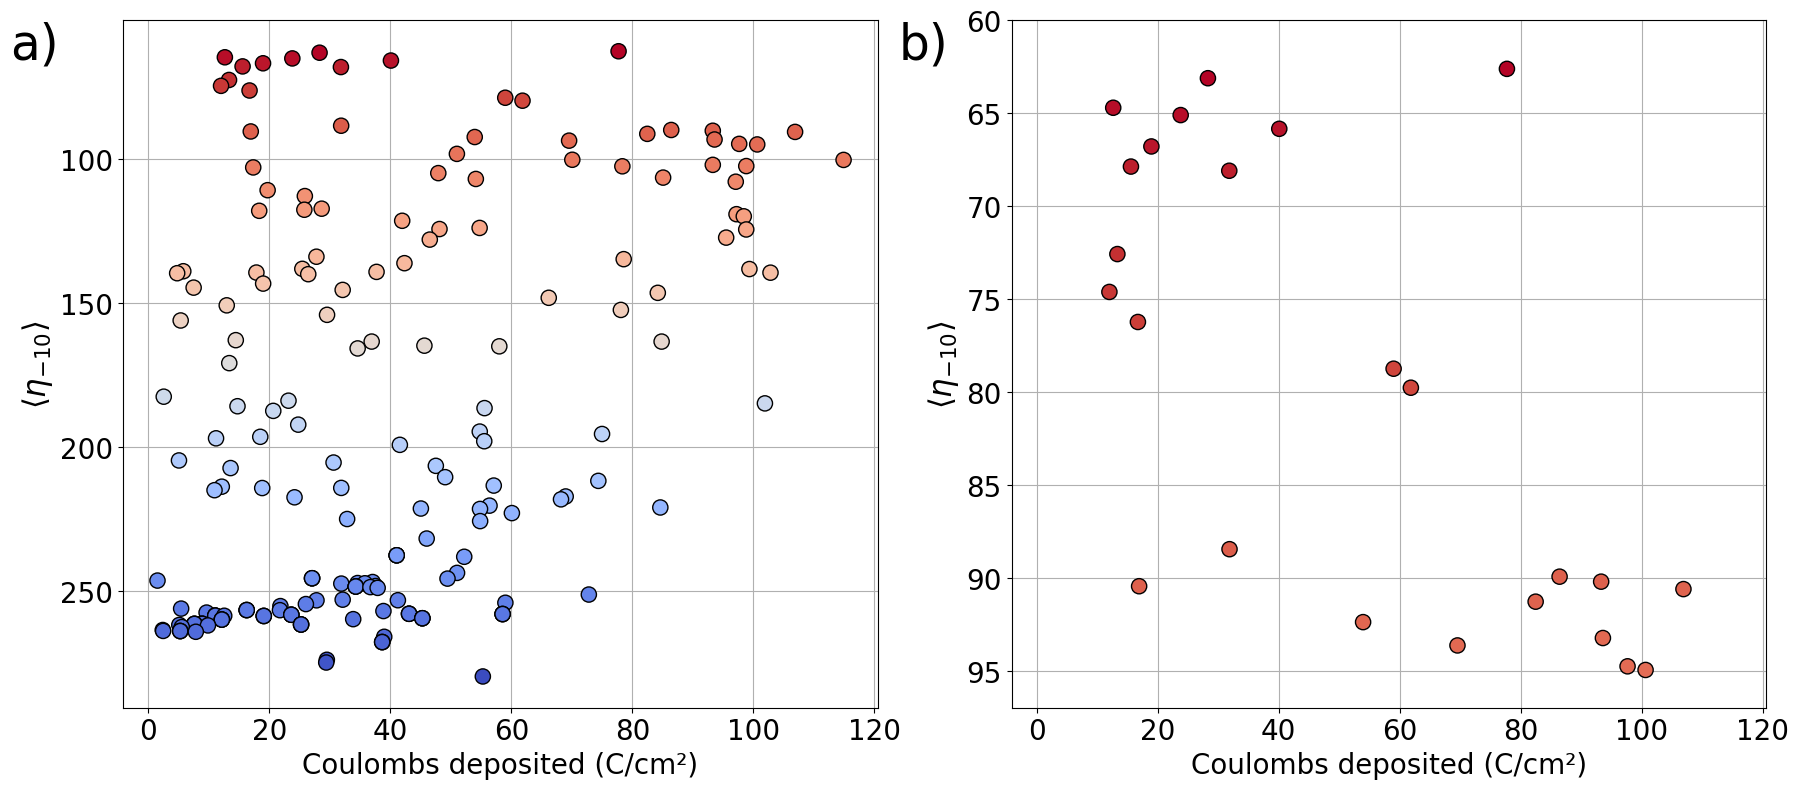

In [11]:
# --------------------------------------------------
# PLOT: FULL + CLOSEUP
# -------------------------------------------------
# -
df = complete_dataset.copy()

x = sorted_df["C_dep"]
y = sorted_df["integrated_area"] / 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax in axes:
    ax.tick_params(axis='both', labelsize=20)  # 🔥 big tick labels

# -------- LEFT: FULL RANGE --------

x_data = sorted_df["C_dep"]

axes[0].scatter(
    x, y,
    c=colors,
    edgecolors='k',
    s=120,
    zorder=10
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Coulombs deposited (C/cm²)", fontsize=20)
axes[0].set_ylabel(r"$\langle \eta_{-10} \rangle$", fontsize=22)
axes[0].grid(True)

# -------- RIGHT: CLOSEUP --------
axes[1].scatter(
    x, y,
    c=colors,
    edgecolors='k',
    s=120,
    zorder=10
)
axes[1].invert_yaxis()

# Zoom window
#axes[1].set_xlim(x.quantile(0.0), x.quantile(0.3))
axes[1].set_ylim(97,60)


axes[1].set_xlabel("Coulombs deposited (C/cm²)", fontsize=20)
axes[1].set_ylabel(r"$\langle \eta_{-10} \rangle$", fontsize=22)
axes[1].grid(True)
# -------- PANEL LABELS --------
axes[0].text(
    -0.15, 1, "a)",
    transform=axes[0].transAxes,
    fontsize=35,
    va='top'
)

axes[1].text(
    -0.15, 1, "b)",
    transform=axes[1].transAxes,
    fontsize=35,
    va='top'
)
plt.tight_layout()
plt.savefig(os.path.join(savepath_params, "Dependence coulomb deposit.png"))
plt.show()